<a href="https://colab.research.google.com/github/IrynaKiriienko/Python_projects/blob/main/Online%20store%20sales%20analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy import stats
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu
!pip install openpyxl


In [ ]:
# Аутентифікація
auth.authenticate_user()

# Створення клієнта для BigQuery
client = bigquery.Client(project="data-analytics-mate")

# SQL-запит
query = """

with event_date as (
SELECT
DATE(TIMESTAMP_MICROS(ep.event_timestamp)) as date,
ga_session_id
FROM `DA.event_params` ep
group by 1,2
)


Select distinct
  event_date.date,
  s.ga_session_id,
  ac.id as account_id,
  ac.is_verified,
  ac.is_unsubscribed,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language,
  sp.name as trafic_channel_name,
  sp.channel as trafic_channel,
  p.item_id,
  p.category,
  p.name as product_name,
  p.price,
  p.short_description as product_short_description
From `DA.session` s
FULL JOIN `DA.account_session` acs
ON s.ga_session_id = acs.ga_session_id
FULL JOIN `DA.account` ac
ON acs.account_id = ac.id
LEFT JOIN event_date
ON s.ga_session_id = event_date.ga_session_id
LEFT JOIN `DA.session_params` sp
ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `DA.order` o
ON s.ga_session_id = o.ga_session_id
JOIN `DA.product` p
ON o.item_id = p.item_id

"""

# Виконання запиту та виведення результату
query_job = client.query(query)
df = query_job.to_dataframe(create_bqstorage_client=False)
df.to_excel('dft.xlsx')
df.head()


,date,ga_session_id,account_id,is_verified,is_unsubscribed,continent,country,device,browser,mobile_model_name,operating_system,language,trafic_channel_name,trafic_channel,item_id,category,product_name,price,product_short_description
0,2021-01-06,6491802401,<NA>,<NA>,<NA>,Americas,United States,mobile,Chrome,Pixel 4 XL,Android,en-us,(organic),Organic Search,89240761,Beds,HOLMSUND,2295.0,Three-seat sofa-bed
1,2021-01-05,191258183,<NA>,<NA>,<NA>,Americas,United States,mobile,Chrome,Pixel 3,Android,en-us,<Other>,Organic Search,80208529,Outdoor furniture,ÄPPLARÖ,445.0,"Bench with backrest, outdoor"
2,2021-01-23,2851909816,<NA>,<NA>,<NA>,Asia,South Korea,mobile,Chrome,Pixel 3,Web,en-us,(referral),Social Search,29239505,Chests of drawers & drawer units,NORDLI,1540.0,"Chest of 8 drawers, 160x99 cm"
3,2020-12-07,406279923,<NA>,<NA>,<NA>,Americas,United States,mobile,Chrome,Pixel 4 XL,Web,None,(organic),Organic Search,70265247,Bookcases & shelving units,MÖLLARP,17.0,"Handle, 106 mm"
4,2020-12-10,5981074091,<NA>,<NA>,<NA>,Asia,Singapore,mobile,Chrome,Pixel 4 XL,Web,None,(organic),Paid Search,9257029,Sofas & armchairs,LIDHULT,3908.0,3-seat sofa


In [ ]:
# Перевіряємо на дублікати
count = df.duplicated().sum()
print(f"Кількість дублікатів: {count}")

Кількість дублікатів: 0


In [ ]:
# Перевіряємо на пропущені дані
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33920 entries, 0 to 33919
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       33920 non-null  dbdate 
 1   ga_session_id              33920 non-null  Int64  
 2   account_id                 2811 non-null   Int64  
 3   is_verified                2811 non-null   Int64  
 4   is_unsubscribed            2811 non-null   Int64  
 5   continent                  33920 non-null  object 
 6   country                    33920 non-null  object 
 7   device                     33920 non-null  object 
 8   browser                    33920 non-null  object 
 9   mobile_model_name          33920 non-null  object 
 10  operating_system           33920 non-null  object 
 11  language                   22784 non-null  object 
 12  trafic_channel_name        33920 non-null  object 
 13  trafic_channel             33920 non-null  obj

In [ ]:
df.describe()

,ga_session_id,account_id,is_verified,is_unsubscribed,item_id,price
count,33920.0,2811.0,2811.0,2811.0,33920.0,33920.000000
mean,4963118159.828979,658777.137673,0.714337,0.160441,47756840.896167,953.148237
std,2885792979.583952,13142.783675,0.45181,0.36708,28766100.487636,1316.651485
min,330355.0,636138.0,0.0,0.0,91415.0,3.000000
25%,2471508924.75,647393.0,0.0,0.0,20346072.0,170.000000
50%,4959472164.0,658248.0,1.0,0.0,49262307.5,445.000000
75%,7442856805.0,670205.0,1.0,0.0,70340807.0,1195.000000
max,9999754183.0,681955.0,1.0,1.0,99930961.0,9585.000000


In [ ]:
#Нормалізація назв
df["trafic_channel_name"]=df["trafic_channel_name"].str.lower()
df["browser"]=df["browser"].str.lower()
df["device"]=df["device"].str.lower()


In [ ]:
# Перша та остання дати замовлення
df["date"].agg([min,max])

/tmp/ipykernel_622/1532195437.py:2: FutureWarning: The provided callable <built-in function min> is currently using Series.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df["date"].agg([min,max])
/tmp/ipykernel_622/1532195437.py:2: FutureWarning: The provided callable <built-in function max> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df["date"].agg([min,max])


,date
min,2020-11-01
max,2021-01-27


In [ ]:
# Кількість непідтвердженних/підвердженних електронних пошт у зареєстрованих аккаунтах
print (df.groupby("is_verified")["is_verified"].count())


is_verified
0     803
1    2008
Name: is_verified, dtype: Int64


In [ ]:
# Відсоток юзерів, які підтвердили аккаунт
print("% of users who unsubscribe", df.groupby("is_unsubscribed")["is_unsubscribed"].count().iloc[1]/df['is_unsubscribed'].count()*100, "%")


% of users who unsubscribe 16.044112415510494 %


In [ ]:
# Кількість користувачів, які не відписалися/відписалися від роззсилки
print (df.groupby("is_unsubscribed")["is_unsubscribed"].count())

is_unsubscribed
0    2360
1     451
Name: is_unsubscribed, dtype: Int64


In [ ]:
# Відсоток юзерів, які відписалися від розсилики
print("% of users verified account", df.groupby("is_verified")["is_verified"].count().iloc[1]/df['is_verified'].count()*100, "%")

% of users verified account 71.43365350409107 %


In [ ]:
print("% of created accounts out of total sessions:", df["account_id"].count()/df['ga_session_id'].count() * 100, "%")

% of created accounts out of total sessions: 8.287146226415095 %


In [ ]:
#Загальна кількість каналів продажів
print (f'Names of trafic_channel_name:', df["trafic_channel_name"].unique())

#Загальна кількість браузерів
print (f'Name of browsers:', df["browser"].unique())

#Загальна кількість девайсів
print (f'Names of devices:',df["device"].unique())



Names of trafic_channel_name: ['(organic)' '<other>' '(referral)' '(direct)' '(data deleted)']
Name of browsers: ['chrome' 'android webview' '<other>' 'firefox' 'safari' 'edge']
Names of devices: ['mobile' 'desktop' 'tablet']


In [ ]:
# Загальний прибуток

print (f'Total price: ', df["price"].sum())
print (f'Total continets: ', len(df["continent"].unique()))
print (f'Total countries: ', len(df["country"].unique()))
print (f'Total categories: ', len(df["category"].unique()))
print (f'Total trafic_channel_names: ', len(df["trafic_channel_name"].unique()))
print (f'Total devices: ', len(df["device"].unique()))
print (f'Total browsers: ', len(df["browser"].unique()))
print (f'Total mobile_model_names: ', len(df["mobile_model_name"].unique()))

Total price:  32330788.2
Total continets:  6
Total countries:  108
Total categories:  14
Total trafic_channel_names:  5
Total devices:  3
Total browsers:  6
Total mobile_model_names:  10


# Описова частина датасету:

загальна кількість колонок - 19

кількість колонок числового типу - 6 (ga_session_id, account_id, is_verified, is_unsubscribed, item_id,  price)

кількість колонок категоріального типу - 12 (continent, country, device, browser, mobile_model_name, operating_system, language, trafic_channel_name, trafic_channel, category, product_name,  product_short_description)

кількість колонок типу datetime - 1

кількість унікальних сесій - 33920

розглядається період від 01.11.2020 до 27.01.2021

чи є пропущені значення - так: 31109 пропущених значень у колонках account_id, is_verified, is_unsubscribed та 11136 пропущених значень у колонці language. Найбільше пропущених значень обумовлено тиv, що багато кількість замовлень було зроблено не з зареєстрованих аккаунтів.

Загальний прибуток склав 32 330 788.2

Загальна кількість охоплених континентів - 6

Загальна кількість охоплених країн - 108

Відсоток зареєстрованих аккаунтів від загальної кількості сесій - 8,29%

Відсоток юзерів, які підтвердили аккаунт - 71,43%

Відсоток юзерів, які відписалися від розсилики  - 16,04%


In [ ]:
#ТОП-3 континенти за продажами
top_3_price_by_continents = df.groupby("continent")["price"].sum().sort_values(ascending=False).iloc[:3]
print(top_3_price_by_continents)

continent
Americas    17864267.5
Asia         7705390.3
Europe       5988506.8
Name: price, dtype: float64


In [ ]:
#ТОП-3 континенти за кількістю замовлень
top_3_orders_by_continents = df.groupby("continent")["ga_session_id"].count().sort_values(ascending=False).iloc[:3]
print(top_3_orders_by_continents)

continent
Americas    18764
Asia         8052
Europe       6323
Name: ga_session_id, dtype: Int64


In [ ]:
#ТОП-5 країн за продажами
top_5_price_by_countries =df.groupby("country")["price"].sum().sort_values(ascending=False).iloc[:5]
print(top_5_price_by_countries)

country
United States     14101033.4
India              2862248.0
Canada             2461500.0
United Kingdom      949138.9
France              721330.8
Name: price, dtype: float64


In [ ]:
#ТОП-5 країн за кількістю замовлень
top_5_orders_by_continents = df.groupby("country")["ga_session_id"].count().sort_values(ascending=False).iloc[:5]
print(top_5_orders_by_continents)

country
United States     14840
India              3076
Canada             2587
United Kingdom     1037
France              689
Name: ga_session_id, dtype: Int64


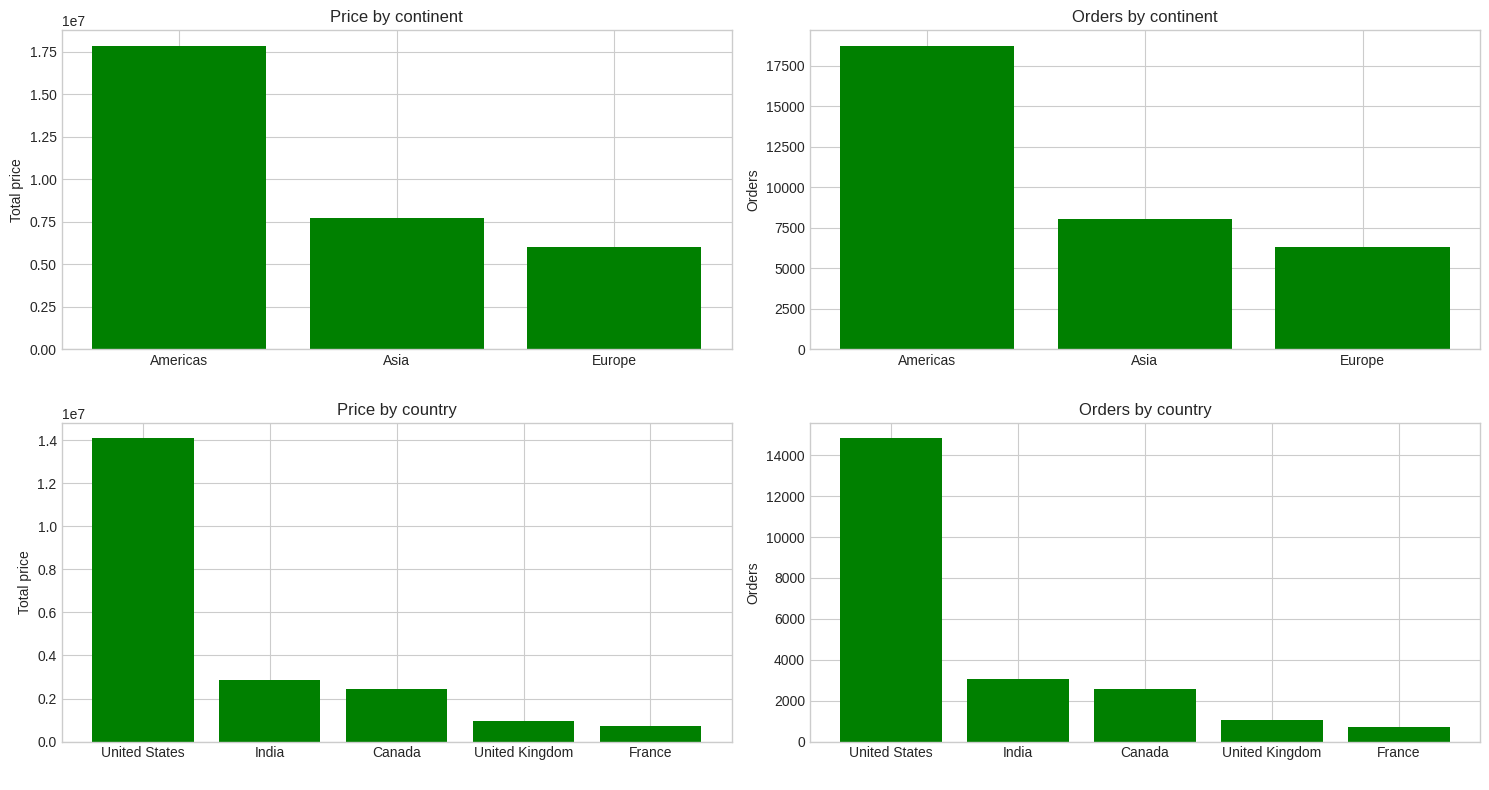

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8))

ax[0,0].bar(top_3_price_by_continents.index, top_3_price_by_continents.values, color="green")
ax[0,0].set_title("Price by continent")
ax[0,0].set_xlabel(" ")
ax[0,0].set_ylabel("Total price")

ax[0,1].bar(top_3_orders_by_continents.index, top_3_orders_by_continents.values, color="green")
ax[0,1].set_title("Orders by continent")
ax[0,1].set_xlabel(" ")
ax[0,1].set_ylabel("Orders")

ax[1,0].bar(top_5_price_by_countries.index, top_5_price_by_countries.values, color="green")
ax[1,0].set_title("Price by country")
ax[1,0].set_xlabel(" ")
ax[1,0].set_ylabel("Total price")

ax[1,1].bar(top_5_orders_by_continents.index, top_5_orders_by_continents.values, color="green")
ax[1,1].set_title("Orders by country")
ax[1,1].set_xlabel(" ")
ax[1,1].set_ylabel("Orders")
plt.tight_layout()
plt.show()

In [ ]:
# топ-10 категорій товарів за загальною сумою продажів
top_10_categories = df.groupby("category")["price"].sum().sort_values(ascending=False).iloc[:10]
print(top_10_categories)

category
Sofas & armchairs                   8435262.0
Chairs                              6209986.8
Beds                                5003328.0
Bookcases & shelving units          3681090.7
Cabinets & cupboards                2370916.5
Outdoor furniture                   2172807.2
Tables & desks                      1823071.5
Chests of drawers & drawer units     915527.5
Bar furniture                        742384.0
Children's furniture                 473120.0
Name: price, dtype: float64


In [ ]:
# топ-10 категорій товарів у країні з найбільшими продажами
top_10_in_USA = df[df["country"]=="United States"].groupby("category")["price"].sum().sort_values(ascending=False).iloc[:10]
print(top_10_in_USA)

category
Sofas & armchairs                   3725475.5
Chairs                              2652849.8
Beds                                2242016.0
Bookcases & shelving units          1587581.4
Cabinets & cupboards                1007191.5
Outdoor furniture                    943285.2
Tables & desks                       790953.0
Chests of drawers & drawer units     389473.0
Bar furniture                        336026.0
Children's furniture                 209095.0
Name: price, dtype: float64


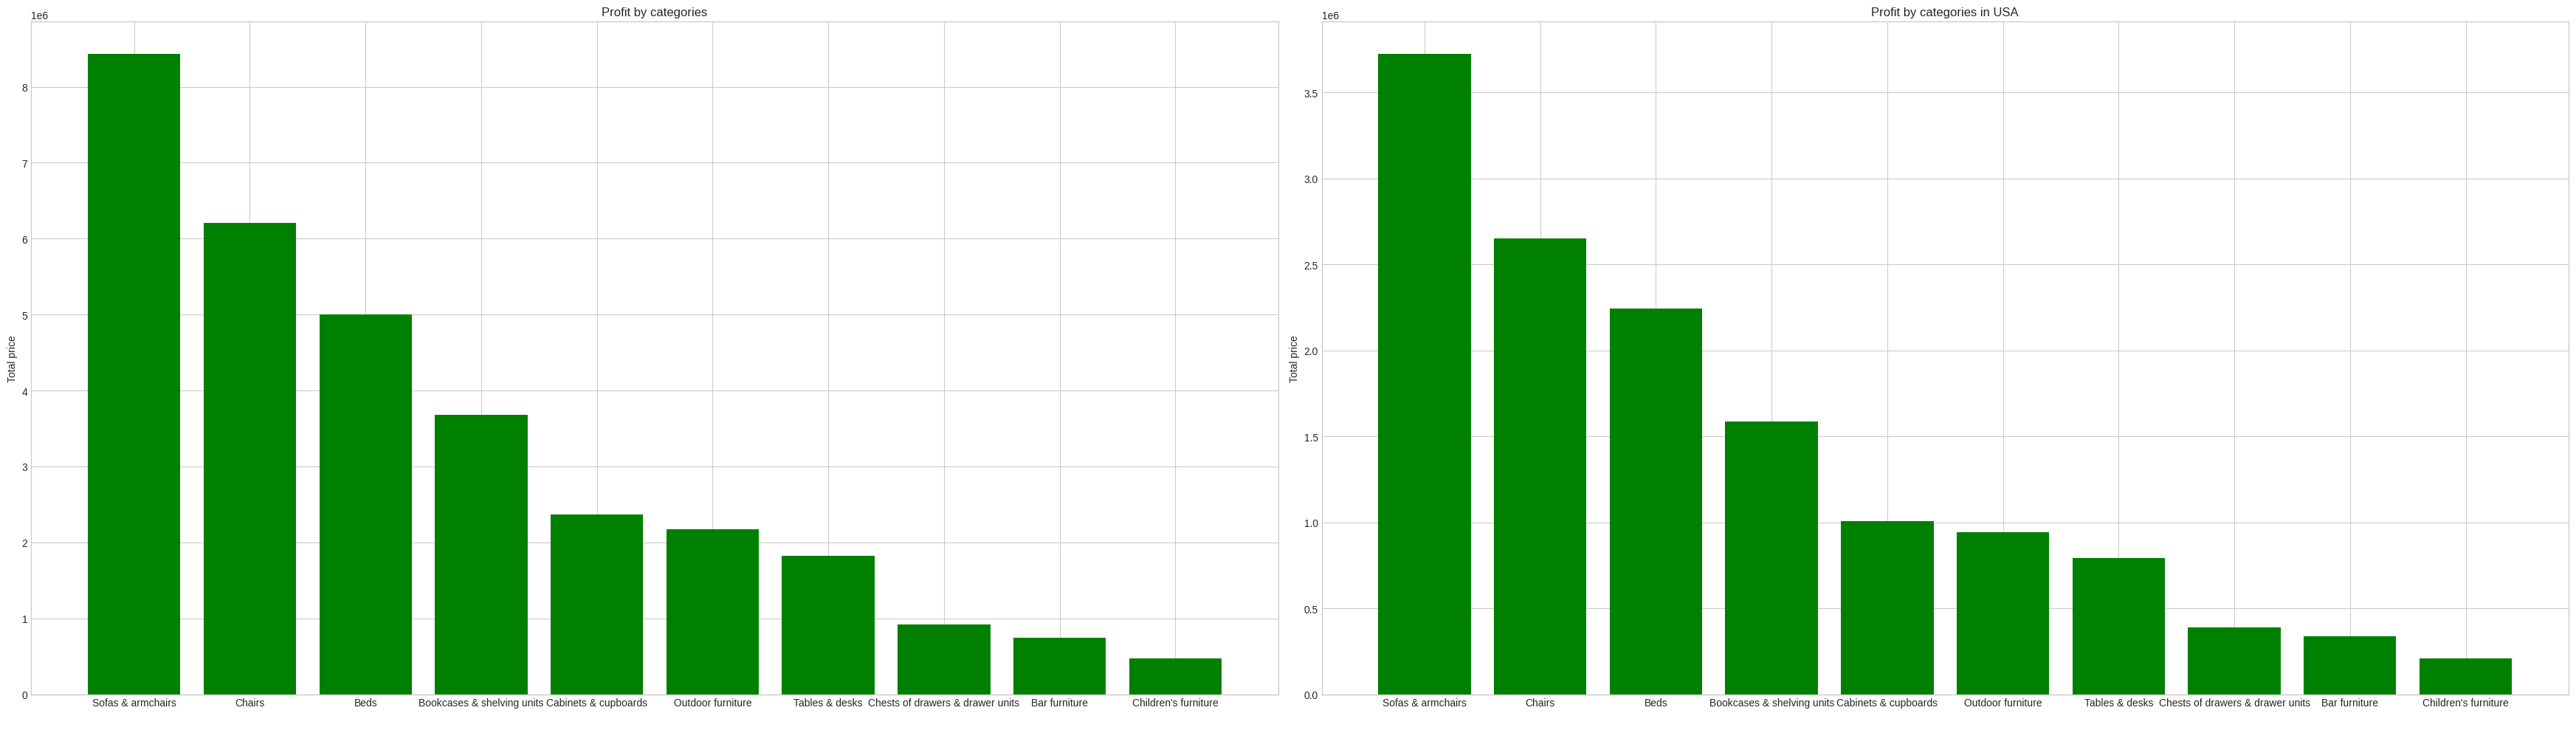

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(35, 10))

ax[0].bar(top_10_categories.index, top_10_categories.values, color="green")
ax[0].set_title("Profit by categories")
ax[0].set_xlabel(" ")
ax[0].set_ylabel("Total price")

ax[1].bar(top_10_in_USA.index, top_10_in_USA.values, color="green")
ax[1].set_title("Profit by categories in USA")
ax[1].set_xlabel(" ")
ax[1].set_ylabel("Total price")

plt.tight_layout()

plt.show()

In [ ]:
# продажі у розрізі типів девайсів (у % від загальних продажів)

device_name = df["device"].str.lower().unique()
print("%", device_name[0], "devices of total devices:", df.groupby("device")["device"].count().iloc[0]/df['device'].count()*100, "%")
print("%", device_name[1], "devices of total devices:", df.groupby("device")["device"].count().iloc[1]/df['device'].count()*100, "%")
print("%", device_name[2], "devices of total devices:", df.groupby("device")["device"].count().iloc[2]/df['device'].count()*100, "%")


% mobile devices of total devices: 58.90919811320755 %
% desktop devices of total devices: 38.926886792452834 %
% tablet devices of total devices: 2.1639150943396226 %


In [ ]:
# продажі у розрізі моделей девайсів (у % від загальних продажів)

device_model = df["mobile_model_name"].str.lower().unique()
print("%", device_model[0], "devices of total devices:", df.groupby("mobile_model_name")["mobile_model_name"].count().iloc[0]/df['mobile_model_name'].count()*100, "%")
print("%", device_model[1], "devices of total devices:", df.groupby("mobile_model_name")["mobile_model_name"].count().iloc[1]/df['mobile_model_name'].count()*100, "%")
print("%", device_model[2], "devices of total devices:", df.groupby("mobile_model_name")["mobile_model_name"].count().iloc[2]/df['mobile_model_name'].count()*100, "%")
print("%", device_model[3], "devices of total devices:", df.groupby("mobile_model_name")["mobile_model_name"].count().iloc[3]/df['mobile_model_name'].count()*100, "%")
print("%", device_model[4], "devices of total devices:", df.groupby("mobile_model_name")["mobile_model_name"].count().iloc[4]/df['mobile_model_name'].count()*100, "%")
print("%", device_model[5], "devices of total devices:", df.groupby("mobile_model_name")["mobile_model_name"].count().iloc[5]/df['mobile_model_name'].count()*100, "%")
print("%", device_model[6], "devices of total devices:", df.groupby("mobile_model_name")["mobile_model_name"].count().iloc[6]/df['mobile_model_name'].count()*100, "%")
print("%", device_model[7], "devices of total devices:", df.groupby("mobile_model_name")["mobile_model_name"].count().iloc[7]/df['mobile_model_name'].count()*100, "%")
print("%", device_model[8], "devices of total devices:", df.groupby("mobile_model_name")["mobile_model_name"].count().iloc[8]/df['mobile_model_name'].count()*100, "%")
print("%", device_model[9], "devices of total devices:", df.groupby("mobile_model_name")["mobile_model_name"].count().iloc[9]/df['mobile_model_name'].count()*100, "%")

% pixel 4 xl devices of total devices: 20.159198113207548 %
% pixel 3 devices of total devices: 28.119103773584907 %
% <other> devices of total devices: 5.548349056603773 %
% chrome devices of total devices: 2.205188679245283 %
% chromebook devices of total devices: 1.2706367924528303 %
% edge devices of total devices: 0.3095518867924528 %
% firefox devices of total devices: 0.35082547169811323 %
% safari devices of total devices: 20.39504716981132 %
% ipad devices of total devices: 1.3738207547169812 %
% iphone devices of total devices: 20.26827830188679 %


In [ ]:
# продажі за джерелами трафіку (у % від загальних продажів)
name_of_chanel = df["trafic_channel_name"].str.lower().unique()
print("%", name_of_chanel[0],"of total trafic_channel_name", df.groupby("trafic_channel_name")["trafic_channel_name"].count().iloc[0]/df['trafic_channel_name'].count()*100, "%")
print("%", name_of_chanel[1],"of total trafic_channel_name", df.groupby("trafic_channel_name")["trafic_channel_name"].count().iloc[1]/df['trafic_channel_name'].count()*100, "%")
print("%", name_of_chanel[2],"of total trafic_channel_name", df.groupby("trafic_channel_name")["trafic_channel_name"].count().iloc[2]/df['trafic_channel_name'].count()*100, "%")
print("%", name_of_chanel[3],"of total trafic_channel_name", df.groupby("trafic_channel_name")["trafic_channel_name"].count().iloc[3]/df['trafic_channel_name'].count()*100, "%")
print("%", name_of_chanel[4],"of total trafic_channel_name", df.groupby("trafic_channel_name")["trafic_channel_name"].count().iloc[4]/df['trafic_channel_name'].count()*100, "%")


% (organic) of total trafic_channel_name 6.129127358490566 %
% <other> of total trafic_channel_name 23.287146226415096 %
% (referral) of total trafic_channel_name 34.0625 %
% (direct) of total trafic_channel_name 17.839033018867926 %
% (data deleted) of total trafic_channel_name 18.682193396226417 %


In [ ]:
#Країни за кількістю користувачів, які підтвердили email
df.groupby("country")["is_verified"].count().sort_values(ascending=False)

,is_verified
country,
United States,1218
India,248
Canada,210
United Kingdom,89
Germany,57
...,...
Qatar,0
Panama,0
Paraguay,0


In [ ]:
# Відмінності у продажах серед підписників та тих хто відписався від розсилки (0-не відписалися, 1-відписалися)
df.groupby("is_unsubscribed")["price"].agg(["sum","count","mean","median"]).sort_values(by="sum",ascending=False)


,sum,count,mean,median
is_unsubscribed,,,,
0,2167434.9,2360,918.404619,395.0
1,432832.6,451,959.717517,450.0


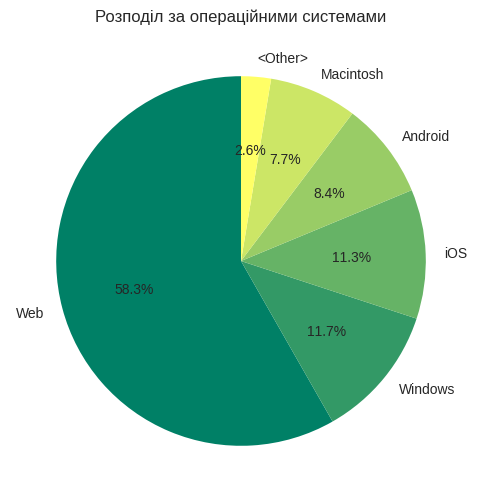

In [ ]:
#Рахуємо частку за операційними системами
device_counts = df['operating_system'].value_counts()


device_counts.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    figsize=(6, 6),
    cmap='summer'
)


plt.title('Розподіл за операційними системами')
plt.ylabel('')
plt.show()

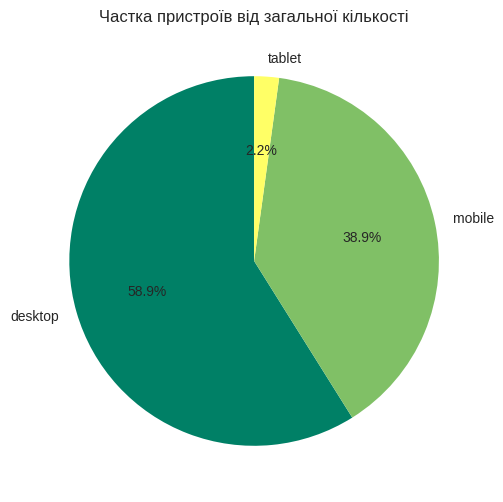

In [ ]:
#Рахуємо частку кожного пристрою
device_counts = df['device'].value_counts()


device_counts.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    figsize=(6, 6),
    cmap='summer'
)


plt.title('Частка пристроїв від загальної кількості')
plt.ylabel('')
plt.show()

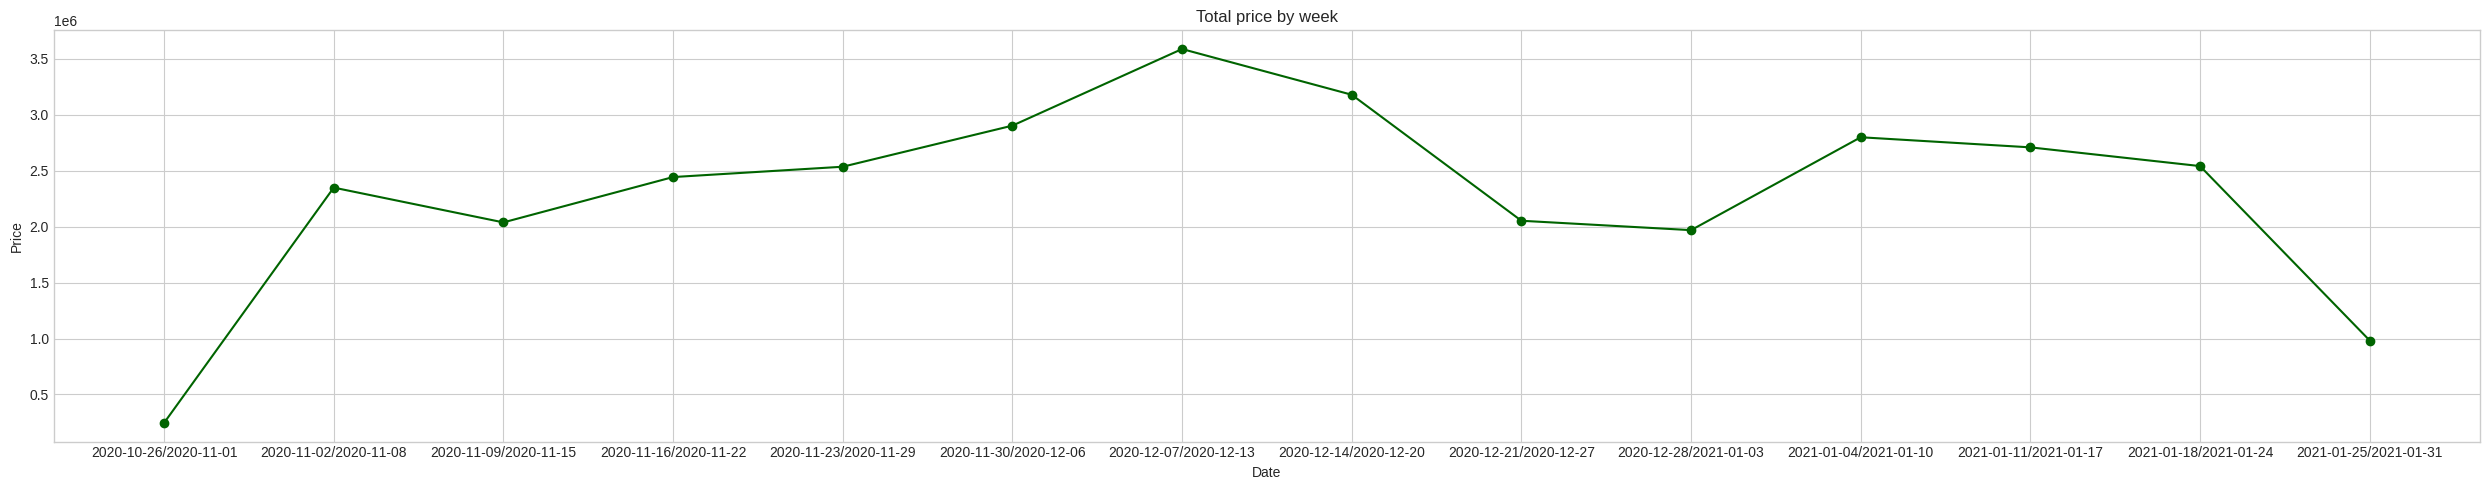

In [ ]:
# Line plot with relplot

df['date'] = pd.to_datetime(df['date'])
total_price= df.groupby(df["date"].dt.to_period("W"))["price"].sum().reset_index()

plt.figure(figsize=(25, 5))
plt.style.use("seaborn-v0_8-whitegrid")

plt.plot(total_price["date"].astype(str),total_price["price"], marker = "o", color = "darkgreen")
plt.title("Total price by week")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()

plt.show()

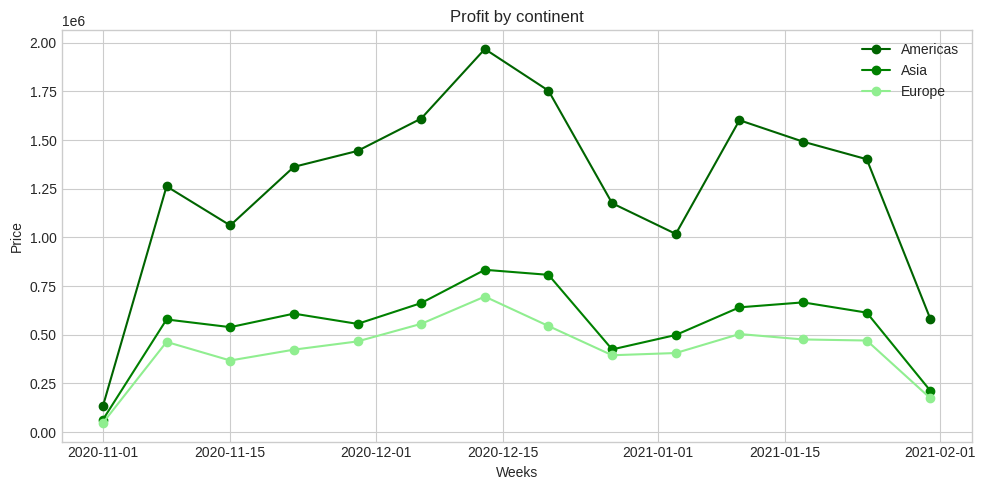

In [ ]:
pivot_tabl_price_by_continent= pd.pivot_table(
    df, values="price", index="date", columns="continent", aggfunc="sum", fill_value=0
)
pivot_tabl_price_by_continent_week = pivot_tabl_price_by_continent.resample('W').sum()

# динаміка продажів в Америці, Азії та Європі

plt.figure(figsize=(10, 5))


Price_by_continent=pivot_tabl_price_by_continent_week.groupby("date")[["Americas","Europe","Asia"]].sum()
plt.plot(Price_by_continent.index, Price_by_continent["Americas"], color="darkgreen", marker = "o", label="Americas")
plt.plot(Price_by_continent.index, Price_by_continent["Asia"], color= "green", marker = "o", label="Asia")
plt.plot(Price_by_continent.index, Price_by_continent["Europe"], color= "lightgreen", marker = "o", label="Europe")
plt.title("Profit by continent")
plt.xlabel("Weeks")
plt.ylabel("Price")

plt.legend()
plt.tight_layout()
plt.show()

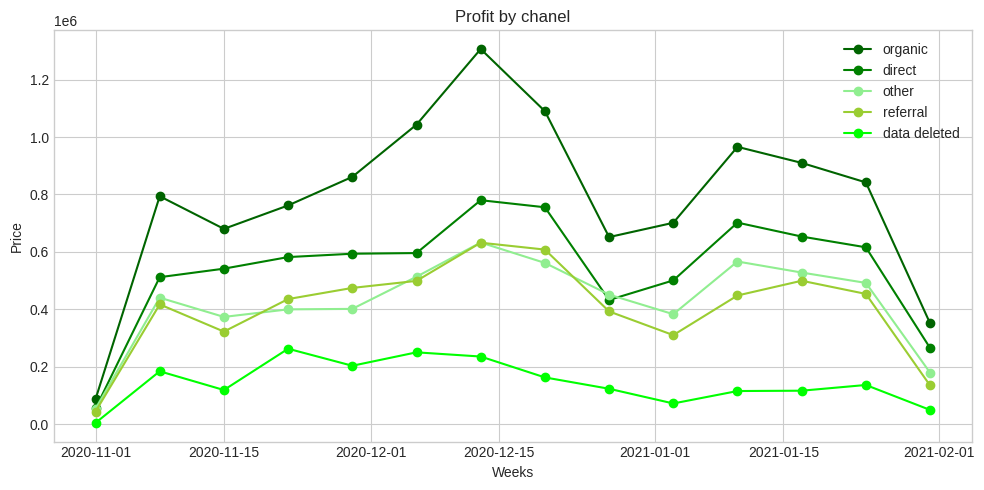

In [ ]:
pivot_tabl_price_by_chanel= pd.pivot_table(
    df, values="price", index="date", columns="trafic_channel_name", aggfunc="sum", fill_value=0
)
pivot_tabl_price_by_chanel_week = pivot_tabl_price_by_chanel.resample('W').sum()

# динаміка продажів по каналах трафіку ['(organic)' '(direct)' '<other>' '(referral)' '(data deleted)']

plt.figure(figsize=(10, 5))


Price_by_chanel=pivot_tabl_price_by_chanel_week.groupby("date")[["(organic)", "(direct)", "<other>", "(referral)", "(data deleted)"]].sum()
plt.plot(Price_by_chanel.index, Price_by_chanel["(organic)"], color="darkgreen", marker = "o", label="organic")
plt.plot(Price_by_chanel.index, Price_by_chanel["(direct)"], color= "green", marker = "o", label="direct")
plt.plot(Price_by_chanel.index, Price_by_chanel["<other>"], color= "lightgreen", marker = "o", label="other")
plt.plot(Price_by_chanel.index, Price_by_chanel["(referral)"], color= "yellowgreen", marker = "o", label="referral")
plt.plot(Price_by_chanel.index, Price_by_chanel["(data deleted)"], color= "lime", marker = "o", label="data deleted")
plt.title("Profit by chanel")
plt.xlabel("Weeks")
plt.ylabel("Price")

plt.legend()
plt.tight_layout()
plt.show()

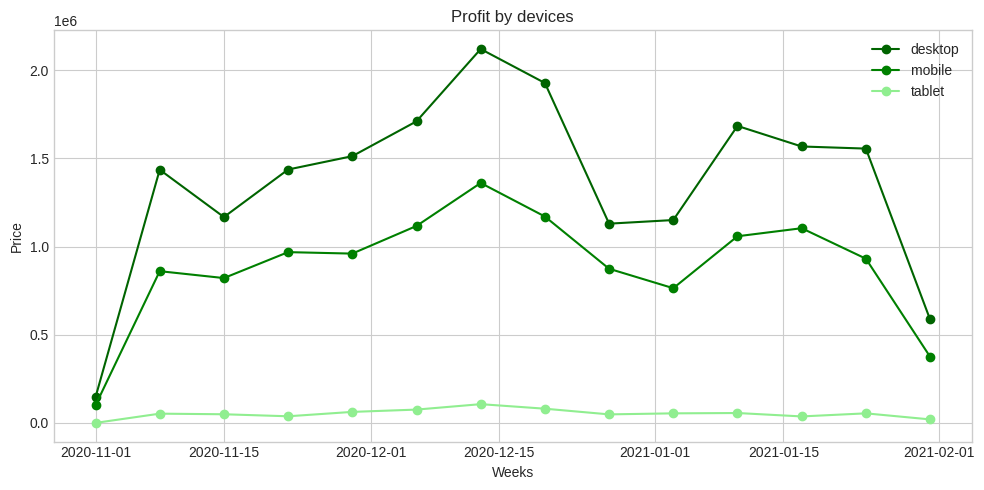

In [ ]:
pivot_tabl_price_by_devices= pd.pivot_table(
    df, values="price", index="date", columns="device", aggfunc="sum", fill_value=0
)
pivot_tabl_price_by_devices_week = pivot_tabl_price_by_devices.resample('W').sum()

# динаміка продажів по девайсам

plt.figure(figsize=(10, 5))


Price_by_devices=pivot_tabl_price_by_devices_week.groupby("date")[["desktop","mobile","tablet"]].sum()
plt.plot(Price_by_devices.index, Price_by_devices["desktop"], color="darkgreen", marker = "o", label="desktop")
plt.plot(Price_by_devices.index, Price_by_devices["mobile"], color= "green", marker = "o", label="mobile")
plt.plot(Price_by_devices.index, Price_by_devices["tablet"], color= "lightgreen", marker = "o", label="tablet")
plt.title("Profit by devices")
plt.xlabel("Weeks")
plt.ylabel("Price")

plt.legend()
plt.tight_layout()
plt.show()


### Аналізуючи динаміку продажів по тижням за період з 01.11.2020 по 01.02.2021, ми бачимо що пік продажів був у проміжку з 07.12.2020 по 13.12.2020 за всіма критеріями, які ми розглядали. Найгірші продажі були у періоди 09.11.2020-15.11.2020 та 21.12.2020-03.01.2021.
### Найбільші продажі були зроблені в Америці, тоді як ринок Азії та Європи приносив більш менш однаковий прибуток, але в Європі прибуток трішки більший.
### В розрізі каналів продажів можна побачити, що найбільші продажі були за organic chanel, а найменші – «data deleted». По іншим каналам продажі були приблизно однакові.
### В розрізі девайсів найпопулярнішим залишається «desktop», але продажі по «mobile» також є доволі високими. Продажі ж по «tablet» майже не приносять доходу.


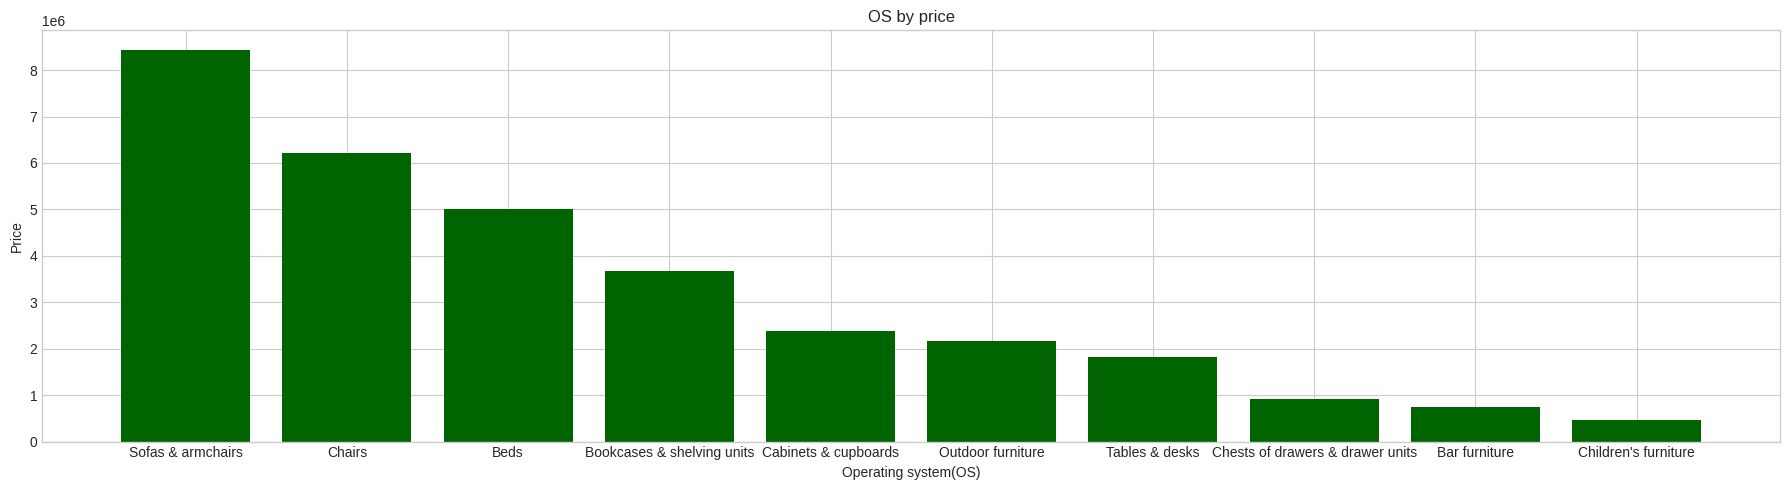

In [ ]:
pivot_table_price_by_category = pd.pivot_table(
    df, values="price", index="category", aggfunc="sum", fill_value=0
)

pivot_table_price_by_category.sort_values(by="price",ascending=False).reset_index()

top_category_by_price = pivot_table_price_by_category.sort_values(by="price",ascending=False).reset_index().iloc[:10]

plt.figure(figsize=(18, 5))

plt.bar(top_category_by_price["category"], top_category_by_price["price"], color="darkgreen")
plt.title("OS by price")
plt.xlabel("Operating system(OS)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

In [ ]:
pivot_table_price_by_country = pd.pivot_table(
    df, values="price", index="country", aggfunc="sum", fill_value=0
)

pivot_table_price_by_country.sort_values(by="price",ascending=False).iloc[:5]

,price
country,
United States,14101033.4
India,2862248.0
Canada,2461500.0
United Kingdom,949138.9
France,721330.8


Text(0, 0.5, 'Price')

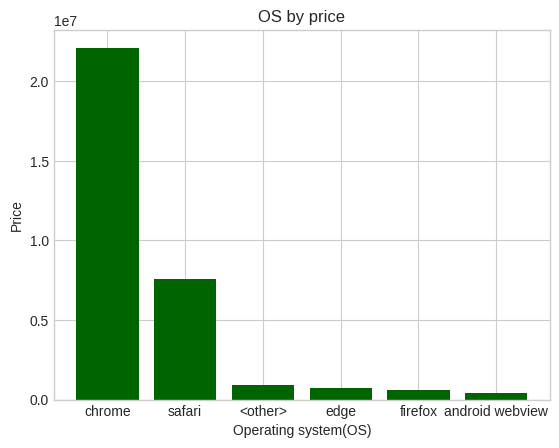

In [ ]:
pivot_table_price_by_browser = pd.pivot_table(
    df, values="price", index="browser", aggfunc="sum", fill_value=0
)

pivot_table_price_by_browser.sort_values(by="price",ascending=False).reset_index()

top_browser_by_price = pivot_table_price_by_browser.sort_values(by="price",ascending=False).reset_index()

plt.bar(top_browser_by_price["browser"], top_browser_by_price["price"], color="darkgreen")
plt.title("OS by price")
plt.xlabel("Operating system(OS)")
plt.ylabel("Price")

Text(0, 0.5, 'Price')

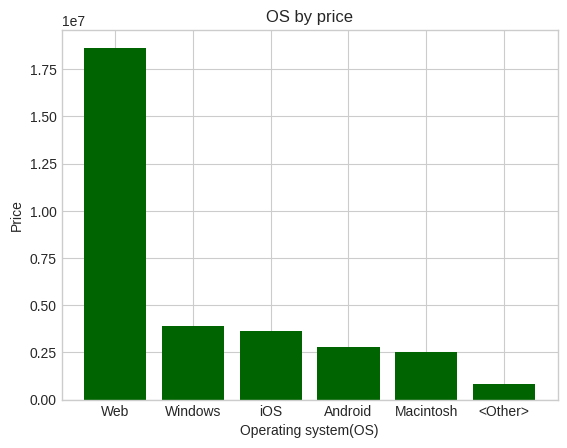

In [ ]:
pivot_table_price_by_os = pd.pivot_table(
    df, values="price", index="operating_system", aggfunc="sum", fill_value=0
)

top_os_by_price = pivot_table_price_by_os.sort_values(by="price",ascending=False).reset_index()

plt.bar(top_os_by_price["operating_system"], top_os_by_price["price"], color="darkgreen")
plt.title("OS by price")
plt.xlabel("Operating system(OS)")
plt.ylabel("Price")

In [ ]:
# Кількість сессій по країнаї в розрізі девайсів та браузерів
pivot_tabl_sessions_by_continents= pd.pivot_table(
    df, values="ga_session_id", index="continent", columns=["device","browser"], aggfunc="count", fill_value=0
)

pivot_tabl_sessions_by_continents.iloc[:6]

device    desktop                             mobile                         \
browser   <other> chrome edge firefox safari <other> android webview chrome   
continent                                                                     
(not set)       1     42    5       1      1       3               1      6   
Africa          1    163   11       4     10       8               4     59   
Americas      128   9345  418     311    866     305             233   3327   
Asia           68   3980  166     134    387     129             103   1485   
Europe         55   3124  151      95    273     103              63   1142   
Oceania         2    203    8       7     22       5               1     62   

device                    tablet                                
browser   firefox safari <other> android webview chrome safari  
continent                                                       
(not set)       0     10       0               0      0      1  
Africa          0     74       1               0      2      4  
Americas       23   3401      32               8    214    153  
Asia            5   1418      23               6     88     60  
Europe          6   1178       7               4     61     61  
Oceania         0     50       1               0      5      3

# Статистичний аналіз взаємозв’язків.

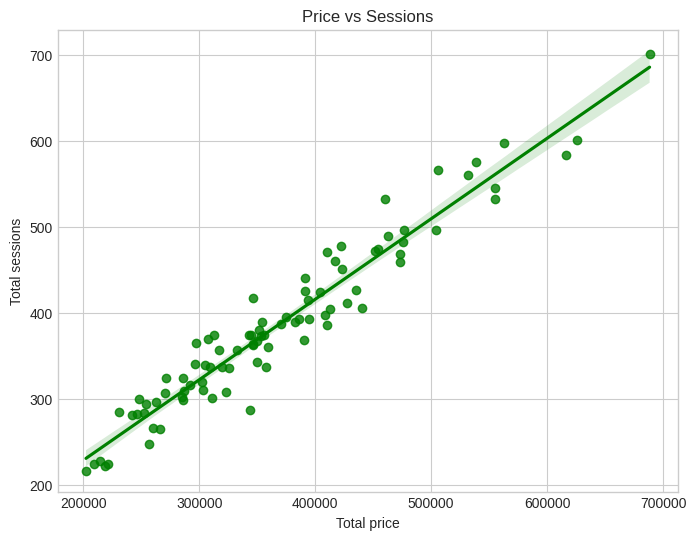

In [ ]:
# Відношення кількісті сесій  до загальні продажі за кожну дату
pivot_tabel_ses_pr_by_date = pd.pivot_table(
    df, values=["price","ga_session_id"], index="date", aggfunc={"price":"sum","ga_session_id":"count"}, fill_value=0
)

sesion_price_by_date = pivot_tabel_ses_pr_by_date.sort_values(by="date", ascending = False).reset_index()

plt.figure(figsize=(8, 6))
sns.regplot(data=sesion_price_by_date, x="price", y="ga_session_id", color="green")
plt.title("Price vs Sessions")
plt.xlabel("Total price")
plt.ylabel("Total sessions")
plt.show()

In [ ]:
# Розраховуємо p-value
print(f"Test statistic and p-value: {pearsonr(sesion_price_by_date["ga_session_id"], sesion_price_by_date["price"])}")

# Розраховуємо кореляцію Пірсона
pearson_corr_pr_ses = sesion_price_by_date["ga_session_id"].corr(sesion_price_by_date["price"])
print(f"Pearson Correlation: {pearson_corr_pr_ses}")


Test statistic and p-value: PearsonRResult(statistic=np.float64(0.9663318179159889), pvalue=np.float64(1.7605212890722528e-52))
Pearson Correlation: 0.9663318179159885


###Було використано коефіцієнт кореляції Пірсона, оскільки ми маємо кількістні нормально розподілені дані, які корелюються між собою. p-value =  1.7605212890722528e-52, тому можна вважати, що ми маємо високу статистичну значущість і ми можемо відхилити нульову гіпотезу. Коєфіцієнт Пірсона складає 0.96, що свідчить про сильний лінійний зв'язок між параметрами.

#

#Кореляція між собою продажів по топ-3 континентах та аналіз статистичної значущість взаємозв’язків

In [ ]:
# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Americas та Asia
print(f"Test statistic and p-value Americas vs Asia: {pearsonr(pivot_tabl_price_by_continent["Americas"], pivot_tabl_price_by_continent["Asia"])}")

# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Americas та Europe
print(f"Test statistic and p-value Americas vs Europe: {pearsonr(pivot_tabl_price_by_continent["Americas"], pivot_tabl_price_by_continent["Europe"])}")

# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Asia та Europe
print(f"Test statistic and p-value Europe vs Asia: {pearsonr(pivot_tabl_price_by_continent["Europe"], pivot_tabl_price_by_continent["Asia"])}")

Test statistic and p-value Americas vs Asia: PearsonRResult(statistic=np.float64(0.705538899553789), pvalue=np.float64(1.6531465652444847e-14))
Test statistic and p-value Americas vs Europe: PearsonRResult(statistic=np.float64(0.6813112348386868), pvalue=np.float64(2.768196778870529e-13))
Test statistic and p-value Europe vs Asia: PearsonRResult(statistic=np.float64(0.6742127563955954), pvalue=np.float64(6.010596875157533e-13))


###Ми використали кореляцію Пірсона і з отриманих даних можна зробити висновок, про сильну лінійну кореляцію за продажами по топ-3 континентам. p-value за кожним з розрахунків є набагато меншим за 0,05, одже ми відхиляємо нульову гіпотезу. Так як ми маємо стійкий лінійний зв'язок і опираючись на графік загальної суми продажів по цим континентам за певні проміжки дати, ми можемо зробити висновок, що данні майже синхронно змінюються і не залежать від подій на відповідних континентах.

#Кореляція між собою продажів за топ-5 категоріями товарів та аналіз статистичної значущість взаємозв’язків.

In [ ]:
pivot_table_price_by_categorydate= pd.pivot_table(
    df, values="price", index="date", columns="category", aggfunc="sum", fill_value=0
)
pivot_table_price_by_categorydate_new = pivot_table_price_by_categorydate.resample('W').sum()

# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Sofas & armchairs та Chairs
print(f"Test statistic and p-value Sofas & armchairs vs Chairs: {pearsonr(pivot_table_price_by_categorydate_new["Sofas & armchairs"], pivot_table_price_by_categorydate_new["Chairs"])}")

# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Sofas & armchairs та Beds
print(f"Test statistic and p-value Sofas & armchairs vs Beds: {pearsonr(pivot_table_price_by_categorydate_new["Sofas & armchairs"], pivot_table_price_by_categorydate_new["Beds"])}")


# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Sofas & armchairs та Bookcases & shelving units
print(f"Test statistic and p-value Sofas & armchairs vs Bookcases & shelving units: {pearsonr(pivot_table_price_by_categorydate_new["Sofas & armchairs"], pivot_table_price_by_categorydate_new["Bookcases & shelving units"])}")


# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Sofas & armchairs та Cabinets & cupboards
print(f"Test statistic and p-value Sofas & armchairs vs Cabinets & cupboards: {pearsonr(pivot_table_price_by_categorydate_new["Sofas & armchairs"], pivot_table_price_by_categorydate_new["Cabinets & cupboards"])}")


# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Chairs та Beds
print(f"Test statistic and p-value Chairs vs Beds: {pearsonr(pivot_table_price_by_categorydate_new["Chairs"], pivot_table_price_by_categorydate_new["Beds"])}")

# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Chairs та Bookcases & shelving units
print(f"Test statistic and p-value Chairs vs Bookcases & shelving units: {pearsonr(pivot_table_price_by_categorydate_new["Chairs"], pivot_table_price_by_categorydate_new["Bookcases & shelving units"])}")


# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Chairs та Cabinets & cupboards
print(f"Test statistic and p-value Chairs vs Cabinets & cupboards: {pearsonr(pivot_table_price_by_categorydate_new["Chairs"], pivot_table_price_by_categorydate_new["Cabinets & cupboards"])}")



# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Beds та Bookcases & shelving units
print(f"Test statistic and p-value Beds vs Bookcases & shelving units: {pearsonr(pivot_table_price_by_categorydate_new["Beds"], pivot_table_price_by_categorydate_new["Bookcases & shelving units"])}")


# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Beds та Cabinets & cupboards
print(f"Test statistic and p-value Beds vs Cabinets & cupboards: {pearsonr(pivot_table_price_by_categorydate_new["Beds"], pivot_table_price_by_categorydate_new["Cabinets & cupboards"])}")



# Розраховуємо коєфіцієнт кореляції та статистичну значущість для Bookcases & shelving units та Cabinets & cupboards
print(f"Test statistic and p-value Bookcases & shelving units vs Cabinets & cupboards: {pearsonr(pivot_table_price_by_categorydate_new["Bookcases & shelving units"], pivot_table_price_by_categorydate_new["Cabinets & cupboards"])}")




Test statistic and p-value Sofas & armchairs vs Chairs: PearsonRResult(statistic=np.float64(0.9220709642478543), pvalue=np.float64(2.7291952408265586e-06))
Test statistic and p-value Sofas & armchairs vs Beds: PearsonRResult(statistic=np.float64(0.943706841514903), pvalue=np.float64(4.066781001591499e-07))
Test statistic and p-value Sofas & armchairs vs Bookcases & shelving units: PearsonRResult(statistic=np.float64(0.9382056058168984), pvalue=np.float64(7.030249952597015e-07))
Test statistic and p-value Sofas & armchairs vs Cabinets & cupboards: PearsonRResult(statistic=np.float64(0.9214162534274356), pvalue=np.float64(2.865541080423356e-06))
Test statistic and p-value Chairs vs Beds: PearsonRResult(statistic=np.float64(0.9537036382376949), pvalue=np.float64(1.2861522718496533e-07))
Test statistic and p-value Chairs vs Bookcases & shelving units: PearsonRResult(statistic=np.float64(0.9661442372885333), pvalue=np.float64(2.021013613755318e-08))
Test statistic and p-value Chairs vs Cabi

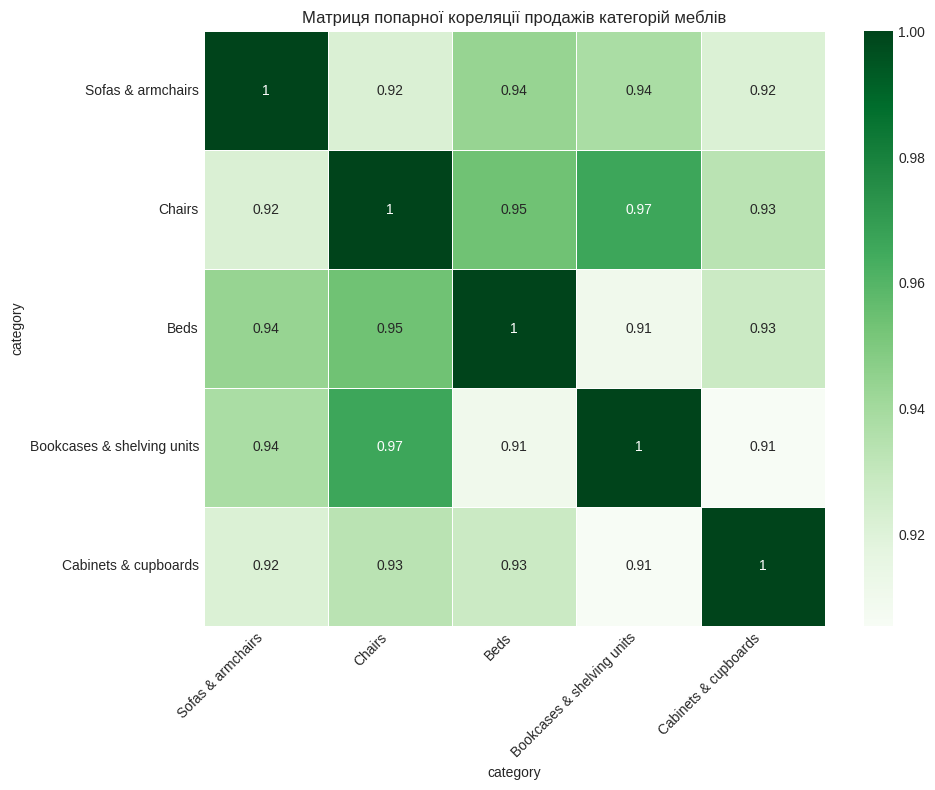

In [ ]:
# Робимо теплову карту по категоріям
categories = [
    "Sofas & armchairs",
    "Chairs",
    "Beds",
    "Bookcases & shelving units",
    "Cabinets & cupboards",

]
corr_matrix = pivot_table_price_by_categorydate_new[categories].corr()


plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Greens",
    linewidths=0.5
)


plt.title("Матриця попарної кореляції продажів категорій меблів")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Так як нам потрібно провести аналіз данних по топ 5 категоріях, то ми можемо або розрахувати кореляцію Пірсона для кожної пари з категорій, але це буде громіздкий важкий код, або ж зробити візуалізацію за допомогою теплової карти, яка зробить матрицю 5х5 і наглядно продемонструє зв'язок між категоріями товарів.
### З першої частини ми можемо взяти значення p-value, яке в нашому випадку <0.05, тобто ми маємо високу статстичну значущість. В другій частині (теплова карта) ми можемо побачити взаємозв'язок продажів між категоріями. Тобто коли зростає одна величина, чи відбувається зростання в якійсь іншій? Як ми можемо побачити, що всі значення більше 0,9, це свідчить про зв'зок між продажами, і можна зробити припущення, що разом з однією категорією найчастіше продається і інша в одному чеку. (Наприклад категорія "Chairs" має високу кореляцію з "Bookcases & sheving units")

# Статистичний аналіз відмінностей між групами.

In [ ]:
#Аналіз продажів за кожну дату зареєстрованих та незареєстрованих користувачів.

pivot_table_price_by_verif_acc= pd.pivot_table(
    df, values="price", index="date", columns="is_verified", aggfunc="sum", fill_value=0
)

group_unverified = pivot_table_price_by_verif_acc[0]
group_verified = pivot_table_price_by_verif_acc[1]


p_unverif = normaltest(group_unverified)[1]
p_verif = normaltest(group_verified)[1]

print(f"p-value для незареєстрованих:", p_unverif)
print(f"p-value для зареєстрованих:", p_verif)


u_stat, p_value = mannwhitneyu(group_unverified, group_verified)
print(f"U-statistic: {u_stat}, p-value: {p_value}")

p-value для незареєстрованих: 1.5761566881974269e-12
p-value для зареєстрованих: 0.1564092821238862
U-statistic: 585.0, p-value: 2.377109341311704e-22


###За результатами підрахунку p-value для зареєстрованих і незареєстрованих користувачів, можна зробити висновок, що ми не можемо підтвердити нормальний розподіл даних для зареєстрованих користувачів, тому обрати параметричний тест ми не можемо. Отже ми обрали непараметричний тест Mана-Уітні для підтвердження статистичної значущості у аналізі. p-value значно менший за 0,05, в=а отже можна з впененістю говорити що є відмінності у поведінці зареєестрованих і незареєстрованих користувачів

In [ ]:
pivot_table_sessions_by_chanel_acc= pd.pivot_table(
    df, values="ga_session_id", index="date", columns ="trafic_channel_name", aggfunc="count", fill_value=0
)

stat, p_value = kruskal(pivot_table_sessions_by_chanel_acc["(data deleted)"], pivot_table_sessions_by_chanel_acc["(direct)"], pivot_table_sessions_by_chanel_acc["(organic)"],pivot_table_sessions_by_chanel_acc["(referral)"],pivot_table_sessions_by_chanel_acc["<other>"])

print(f"Kruskal-Wallis statistic: {stat}")
print(f"P-value: {p_value}")


Kruskal-Wallis statistic: 316.49578694946706
P-value: 2.991484709274608e-67


### Проаналізуваши кількість сесій по різним каналам трафіку ми отримали p-value <0.05, а отже кількість сесій у різних каналах трафіку кардинально відрізняється між собою. Можна зробити висновок, що ці розбіжності не є випадковим шумом чи результатом сезонності

# https://public.tableau.com/app/profile/iryna.kiriienko/viz/AnalyticsofSales/Dashboard1?publish=yes


# https://public.tableau.com/app/profile/iryna.kiriienko/viz/AnalyticsofSales/Dashboard2?publish=yes